In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Load the tuned model from Phase 6
best_rf = joblib.load("models/best_random_forest.pkl")

# Load the same processed data used for training/testing
train = pd.read_csv("data/processed/train.csv")
test = pd.read_csv("data/processed/test.csv")

X_train = train.drop("Converted", axis=1)
y_train = train["Converted"]

X_test = test.drop("Converted", axis=1)
y_test = test["Converted"]

print("Model loaded:", best_rf)
print("X_test shape:", X_test.shape)

Model loaded: RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=4,
                       min_samples_split=5, n_estimators=500, random_state=42)
X_test shape: (2400, 17)


In [2]:
# TreeExplainer is optimized for tree-based models like Random Forest
explainer = shap.TreeExplainer(best_rf)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats across versions:
# newer shap: 3D array (samples, features, classes) -> take class 1 (Purchase)
# older shap: list of 2 arrays [class0, class1] -> take index 1
if isinstance(shap_values, list):
    sv_purchase = shap_values[1]
elif shap_values.ndim == 3:
    sv_purchase = shap_values[:, :, 1]
else:
    sv_purchase = shap_values

print("SHAP values shape:", sv_purchase.shape)

SHAP values shape: (2400, 17)


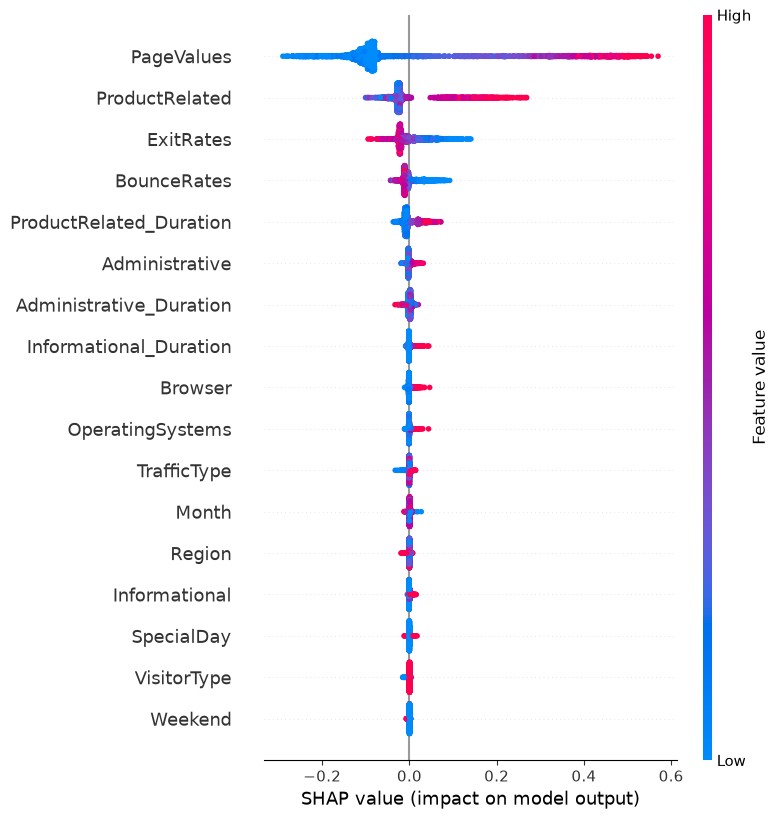

In [5]:
plt.figure()
shap.summary_plot(sv_purchase, X_test, feature_names=X_test.columns, show=False)
plt.tight_layout()
plt.savefig("docs/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
import os

# Check where the notebook is actually running from
print("Current working directory:", os.getcwd())

# Make sure docs folder exists relative to this location
os.makedirs("docs", exist_ok=True)
print("docs folder ready")

Current working directory: C:\Ecommerce Purchase Intent Prediction
docs folder ready


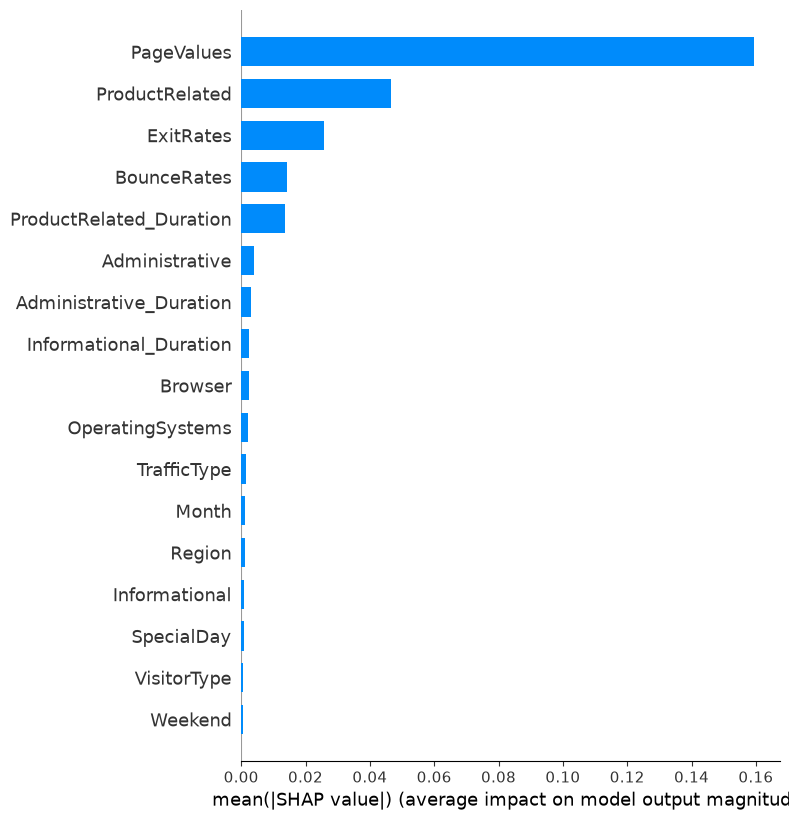

In [6]:
plt.figure()
shap.summary_plot(sv_purchase, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("docs/shap_feature_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

Actual label: 0
Predicted probability of purchase: 0.0028396750477981364


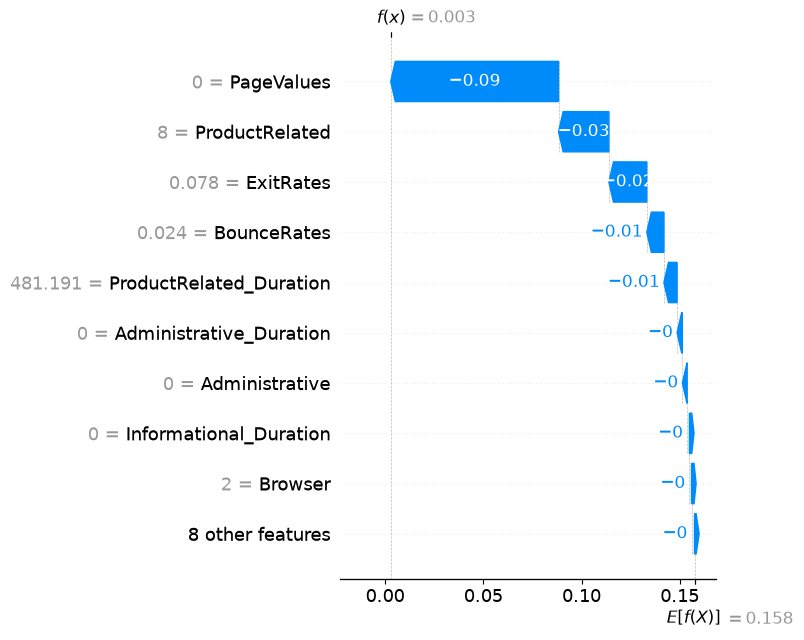

In [7]:
sample_idx = 0

print("Actual label:", y_test.iloc[sample_idx])
print("Predicted probability of purchase:", best_rf.predict_proba(X_test.iloc[[sample_idx]])[0][1])

shap_explanation = shap.Explanation(
    values=sv_purchase[sample_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
)

plt.figure()
shap.plots.waterfall(shap_explanation, show=False)
plt.tight_layout()
plt.savefig("docs/shap_local_explanation_sample0.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Purchase", "Purchase"],
    mode="classification",
    random_state=42
)

print("LIME explainer ready")

LIME explainer ready


In [10]:
sample_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=best_rf.predict_proba,
    num_features=10
)

# Save as HTML report (LIME doesn't export clean PNGs directly)
lime_exp.save_to_file("docs/lime_local_explanation_sample0.html")

# Print as plain list — feature condition + weight
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

C:\Ecommerce Purchase Intent Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


PageValues <= 0.00: -0.2771
ProductRelated <= 11.00: -0.0330
ExitRates > 0.07: -0.0252
0.02 < BounceRates <= 0.03: -0.0156
268.98 < ProductRelated_Duration <= 498.93: -0.0122
1.00 < Browser <= 2.00: -0.0072
SpecialDay <= 0.00: 0.0072
Month <= 5.00: 0.0066
Weekend <= 0.00: -0.0056
TrafficType <= 6.00: -0.0045


## Explainability Summary

**Global drivers (SHAP):** PageValues is by far the strongest predictor of purchase 
intent, followed by ProductRelated, ExitRates, and BounceRates. This aligns with 
e-commerce intuition — visitors who reach high-value product pages and don't bounce 
quickly are far more likely to convert.

**Local explanation agreement:** For a sample test case (index 0), both SHAP and LIME 
independently identified the same top features (PageValues, ProductRelated, ExitRates, 
BounceRates) as driving the "no purchase" prediction, with consistent direction. This 
cross-validation between two different XAI methods increases confidence in the model's 
reasoning.

**Artifacts saved:**
- `docs/shap_summary_plot.png` — global feature impact (beeswarm)
- `docs/shap_feature_importance_bar.png` — global feature ranking
- `docs/shap_local_explanation_sample0.png` — single-prediction waterfall
- `docs/lime_local_explanation_sample0.html` — LIME's independent local explanation